## Problem Statement

Using ```heart.csv``` selected dataset, complete the following tasks:

* Load and explore the dataset.

* Perform appropriate data preprocessing (handle missing values, encode categorical variables, remove duplicates if necessary, and scale features where appropriate).

* Split the dataset into training and testing sets.

* Build and evaluate the following classification models:

1) Support Vector Machine (SVM)
2) k-Nearest Neighbors (kNN)
3) Decision Tree

* Compare the performance of the three models using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

* Perform hyperparameter tuning for at least one model and compare the results before and after tuning.

* Conclude which model performed best and justify your findings.

#### Additional Requirements
* Include clear comments in your code.

* Explain every preprocessing step and modeling decision.

* Use visualizations where appropriate.



In [78]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score
import warnings
warnings.filterwarnings('ignore')

In [80]:
df = pd.read_csv("heart.csv")
df.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
328,52,M,ASY,95,0,1,Normal,82,Y,0.8,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
558,58,M,NAP,137,232,0,ST,124,Y,1.4,Flat,1
230,37,M,ASY,130,315,0,Normal,158,N,0.0,Up,0
136,43,F,ATA,120,215,0,ST,175,N,0.0,Up,0
405,35,M,ASY,120,0,1,Normal,130,Y,1.2,Flat,1
290,48,M,NAP,110,211,0,Normal,138,N,0.0,Up,0
899,61,M,ASY,148,203,0,Normal,161,N,0.0,Up,1
462,59,M,ASY,122,233,0,Normal,117,Y,1.3,Down,1
115,33,F,ASY,100,246,0,Normal,150,Y,1.0,Flat,1


#### Exploratory Data Analysis

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [84]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [86]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [90]:
df.select_dtypes(include='object')

""
0
1
2
3
4
...
913
914
915
916


#### Encoding

In [91]:
df = pd.get_dummies(df,drop_first=True)
bool_colms = df.select_dtypes(include="bool").columns
df[bool_colms] = df[bool_colms].astype(int)

In [92]:
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_M              918 non-null    int64  
 8   ChestPainType_ATA  918 non-null    int64  
 9   ChestPainType_NAP  918 non-null    int64  
 10  ChestPainType_TA   918 non-null    int64  
 11  RestingECG_Normal  918 non-null    int64  
 12  RestingECG_ST      918 non-null    int64  
 13  ExerciseAngina_Y   918 non-null    int64  
 14  ST_Slope_Flat      918 non-null    int64  
 15  ST_Slope_Up        918 non-null    int64  
dtypes: float64(1), int64(15)
memory usage

#### Correlation

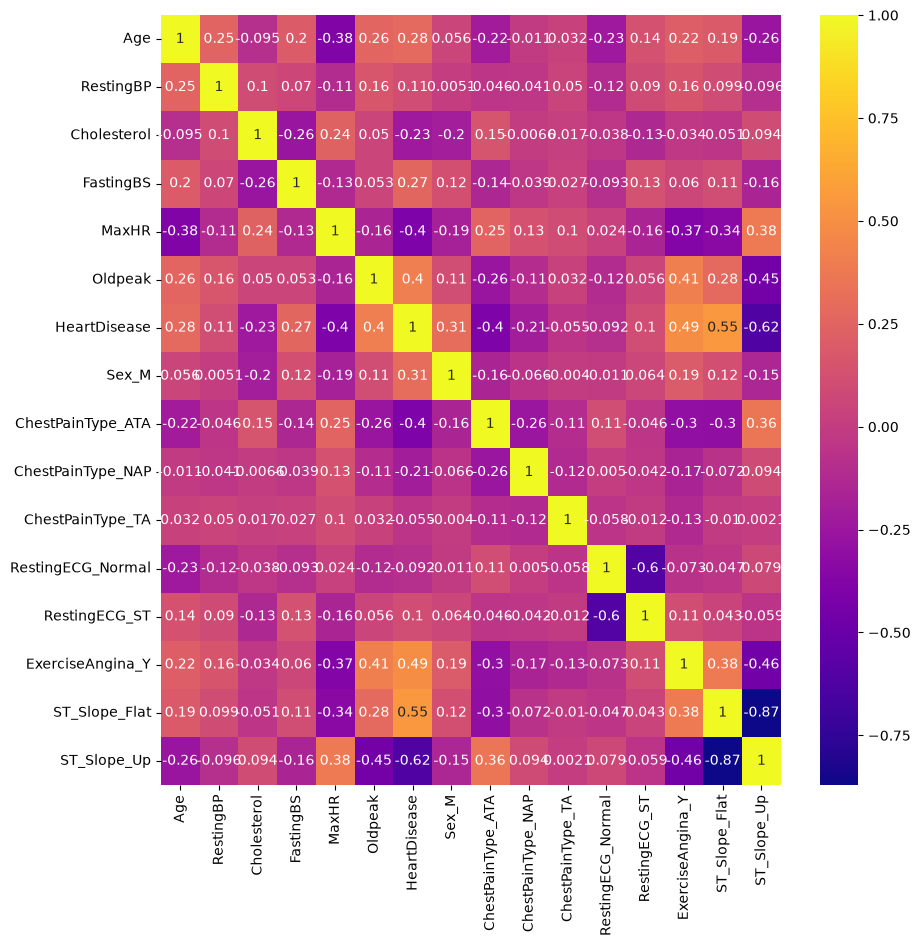

In [94]:
corr_values = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_values,cmap='plasma',annot=True)
plt.savefig('correlation.jpg')
plt.show()

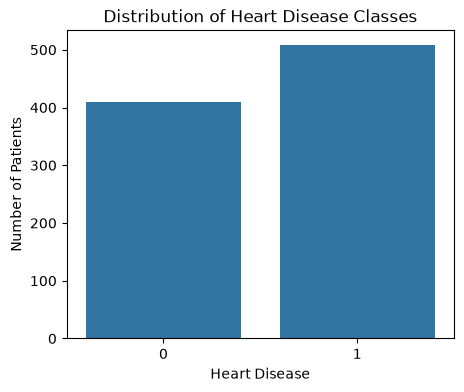

In [151]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='HeartDisease',
    data=df
)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.show()

<Axes: xlabel='Age', ylabel='Cholesterol'>

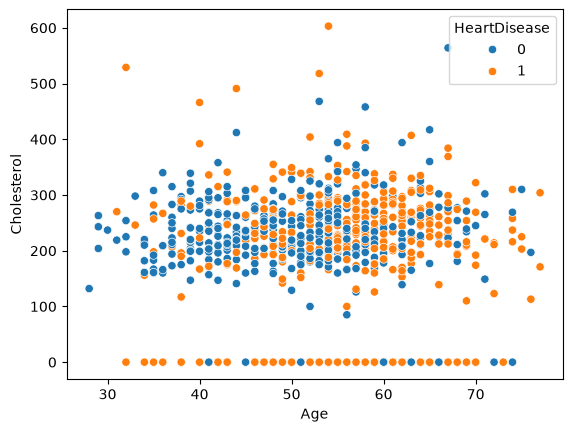

In [152]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Cholesterol',
    hue='HeartDisease'
)

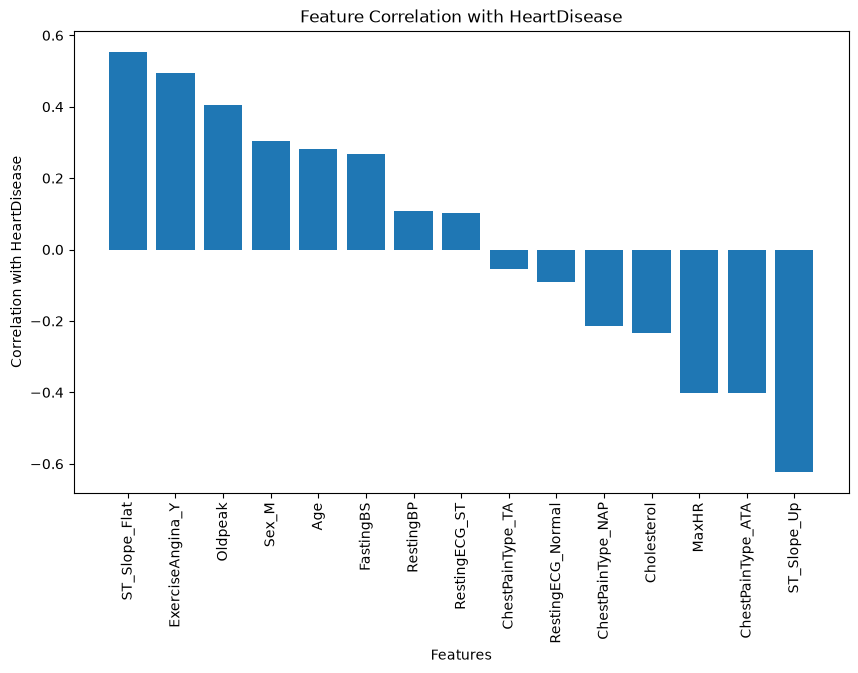

In [95]:
feature_corr = (
    df.corr(numeric_only=True)['HeartDisease']
      .drop('HeartDisease')
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(feature_corr.index, feature_corr.values)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with HeartDisease")
plt.title("Feature Correlation with HeartDisease")
plt.show()

In [96]:
feature_corr

ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
Oldpeak              0.403951
Sex_M                0.305445
Age                  0.282039
FastingBS            0.267291
RestingBP            0.107589
RestingECG_ST        0.102527
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

In [97]:
feature_imp = abs(df.corr(numeric_only=True)['HeartDisease'].drop('HeartDisease')).sort_values(ascending=False)

In [98]:
feature_imp

ST_Slope_Up          0.622164
ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
Oldpeak              0.403951
ChestPainType_ATA    0.401924
MaxHR                0.400421
Sex_M                0.305445
Age                  0.282039
FastingBS            0.267291
Cholesterol          0.232741
ChestPainType_NAP    0.212964
RestingBP            0.107589
RestingECG_ST        0.102527
RestingECG_Normal    0.091580
ChestPainType_TA     0.054790
Name: HeartDisease, dtype: float64

In [99]:
X = df[feature_imp.index]

In [100]:
y = df[['HeartDisease']]

In [101]:
X.shape

(918, 15)

In [102]:
y.shape

(918, 1)

#### Splitting the dataset

In [103]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)

#### Standardization

In [104]:
scalar = StandardScaler()
X_train_fit = scalar.fit_transform(X_train)
X_test_fit = scalar.transform(X_test)

### 1) KNN model

In [105]:
model_KNN = KNeighborsClassifier(n_neighbors=7)

In [106]:
model_KNN.fit(X_train_fit,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [107]:
y_pred = model_KNN.predict(X_test_fit)

#### Checking the accuracy

In [108]:
score = {}
for i in range(3,16,2):
    model_KNN = KNeighborsClassifier(n_neighbors=i)
    model_KNN.fit(X_train_fit,y_train)
    y_pred = model_KNN.predict(X_test_fit)
    score[i]=accuracy_score(y_test,y_pred)
score
    

{3: 0.875,
 5: 0.8858695652173914,
 7: 0.8804347826086957,
 9: 0.875,
 11: 0.875,
 13: 0.8804347826086957,
 15: 0.8804347826086957}

In [109]:
print("Metrics for KNN for neighbour = 7")

Metrics for KNN for neighbour = 7


In [110]:
print("Accuracy")
print(accuracy_score(y_test,y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("Precision Score")
print(precision_score(y_test,y_pred))
print("F1_Score")
print(f1_score(y_test,y_pred))

Accuracy
0.8804347826086957
Confusion Matrix
[[67 15]
 [ 7 95]]
Precision Score
0.8636363636363636
F1_Score
0.8962264150943396


#### Support Vector Classfier

In [117]:
model_svc = SVC(C= 10, gamma= 0.01, kernel = 'rbf')
model_svc.fit(X_train_fit,y_train)
y_pred_svc = model_svc.predict(X_test_fit)

In [118]:
print("Accuracy")
print(accuracy_score(y_test,y_pred_svc))
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred_svc))
print("Precision Score")
print(precision_score(y_test,y_pred_svc))
print("F1_Score")
print(f1_score(y_test,y_pred_svc))

Accuracy
0.8913043478260869
Confusion Matrix
[[67 15]
 [ 5 97]]
Precision Score
0.8660714285714286
F1_Score
0.9065420560747663


#### Hyperparamater Tuning

In [113]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1, 1]
    }
]

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_fit, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.8691361476097288


#### Decision Tree Classfier

In [142]:
model_decision = DecisionTreeClassifier(max_depth=8,min_samples_leaf=9,max_features= "sqrt",min_samples_split=10,criterion= "entropy")

In [149]:
model_decision.fit(X_train,y_train)
y_pred_dec = model_decision.predict(X_test)

In [153]:
print("Accuracy")
print(accuracy_score(y_test,y_pred_dec))
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred_dec))
print("Precision Score")
print(precision_score(y_test,y_pred_dec))
print("F1_Score")
print(f1_score(y_test,y_pred_dec))

Accuracy
0.8532608695652174
Confusion Matrix
[[60 22]
 [ 5 97]]
Precision Score
0.8151260504201681
F1_Score
0.8778280542986425


#### Performance Evaluation

| Model                  | Accuracy | Precision |  F1-Score |                                                           |
| ---------------------- | -------: | --------: |  -------: | -
| Decision Tree          |   85.32% |     81.51 |   87.78 |                    
| Support Vector Machine    |   89% |     86 |   90 | 
| K-Nearest Neighbors |   88% |     86 |   89 |


#### Conclusion 

Three machine learning algorithms: Decision Tree, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM), were implemented and evaluated for heart disease classification. Before model training, the dataset was preprocessed by encoding categorical variables, splitting the data into training and testing sets, and standardizing features for SVM and KNN to prevent data leakage and improve model performance.

The models were evaluated using Accuracy, Precision, Recall, F1-score, and the Confusion Matrix. Among the three algorithms, SVM achieved the best overall performance, producing the highest accuracy and F1-score. 